# Notebook 01 — Inspección Inicial del Dataset REFIT

**Proyecto Fin de Máster — MUCSI, Universidad de Deusto**  
**Dataset:** REFIT Electrical Load Measurements (Zenodo doi:10.5281/zenodo.5063428)  
**Objetivo:** Carga, inspección estructural y análisis exploratorio inicial de los tres hogares de trabajo.  
**Ejecutar de arriba a abajo sin modificaciones.**

---

## Índice
1. [Configuración e importaciones](#1)
2. [Carga de datos](#2)
3. [Estructura y tipos de datos](#3)
4. [Rango temporal y granularidad](#4)
5. [Valores nulos y columna Issues](#5)
6. [Duplicados](#6)
7. [Estadísticas descriptivas](#7)
8. [Distribución del consumo agregado](#8)
9. [Series temporales — primeros 7 días](#9)
10. [Comparativa entre hogares](#10)
11. [Resumen final](#11)

## 1. Configuración e importaciones <a id='1'></a>

In [1]:
# ============================================================
# Importaciones y configuración global
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Semilla de reproducibilidad (fija en todo el proyecto)
SEMILLA = 42
np.random.seed(SEMILLA)

# Suprimir avisos no críticos
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (14, 4),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Rutas
RUTA_RAW  = '../datos/raw/'
RUTA_FIGS = '../resultados/figuras/'
os.makedirs(RUTA_FIGS, exist_ok=True)

# Hogares de trabajo
HOGARES = ['House1', 'House2', 'House3']

# Versiones de librerías (documentación de reproducibilidad)
print('=== Versiones de librerías ===')
print(f'  pandas      : {pd.__version__}')
print(f'  numpy       : {np.__version__}')
print(f'  matplotlib  : {plt.matplotlib.__version__}')
print(f'  seaborn     : {sns.__version__}')
print(f'  SEMILLA     : {SEMILLA}')
print('==============================')

=== Versiones de librerías ===
  pandas      : 2.3.3
  numpy       : 2.3.5
  matplotlib  : 3.10.7
  seaborn     : 0.13.2
  SEMILLA     : 42


## 2. Carga de datos <a id='2'></a>

In [2]:
# ============================================================
# Carga de los tres CSVs en un diccionario de DataFrames
# La columna 'Time' se parsea como datetime desde el inicio
# ============================================================

def cargar_hogar(nombre_hogar: str) -> pd.DataFrame:
    """Carga el CSV de un hogar REFIT y prepara el índice temporal."""
    ruta = os.path.join(RUTA_RAW, f'CLEAN_{nombre_hogar}.csv')
    df = pd.read_csv(
        ruta,
        parse_dates=['Time'],
        infer_datetime_format=True,
    )
    df = df.set_index('Time')
    df.index.name = 'timestamp'
    df['hogar'] = nombre_hogar  # columna identificadora
    return df

datos = {}
for hogar in HOGARES:
    print(f'Cargando {hogar}...', end=' ')
    datos[hogar] = cargar_hogar(hogar)
    tam_mb = os.path.getsize(os.path.join(RUTA_RAW, f'CLEAN_{hogar}.csv')) / 1024**2
    print(f'{len(datos[hogar]):,} filas | {tam_mb:.1f} MB en disco')

print('\nCarga completada.')

Cargando House1... 

6,960,008 filas | 382.3 MB en disco
Cargando House2... 

5,733,526 filas | 310.3 MB en disco
Cargando House3... 

6,994,594 filas | 388.4 MB en disco

Carga completada.


## 3. Estructura y tipos de datos <a id='3'></a>

In [3]:
# ============================================================
# Inspección de columnas, tipos y memoria RAM por hogar
# ============================================================

for hogar, df in datos.items():
    mem_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f'\n{'='*50}')
    print(f'  {hogar} — {df.shape[0]:,} filas x {df.shape[1]} columnas | {mem_mb:.1f} MB en RAM')
    print(f'{'='*50}')
    print(df.dtypes.to_string())


  House1 — 6,960,008 filas x 13 columnas | 1055.4 MB en RAM
Unix           int64
Aggregate      int64
Appliance1     int64
Appliance2     int64
Appliance3     int64
Appliance4     int64
Appliance5     int64
Appliance6     int64
Appliance7     int64
Appliance8     int64
Appliance9     int64
Issues         int64
hogar         object



  House2 — 5,733,526 filas x 13 columnas | 869.4 MB en RAM
Unix           int64
Aggregate      int64
Appliance1     int64
Appliance2     int64
Appliance3     int64
Appliance4     int64
Appliance5     int64
Appliance6     int64
Appliance7     int64
Appliance8     int64
Appliance9     int64
Issues         int64
hogar         object

  House3 — 6,994,594 filas x 13 columnas | 1060.6 MB en RAM
Unix           int64
Aggregate      int64
Appliance1     int64
Appliance2     int64
Appliance3     int64
Appliance4     int64
Appliance5     int64
Appliance6     int64
Appliance7     int64
Appliance8     int64
Appliance9     int64
Issues         int64
hogar         object


In [4]:
# Vista de las primeras y últimas filas de House1 como ejemplo representativo
print('--- Primeras 3 filas (House1) ---')
display(datos['House1'].head(3))
print('\n--- Últimas 3 filas (House1) ---')
display(datos['House1'].tail(3))

--- Primeras 3 filas (House1) ---


,Unix,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9,Issues,hogar
timestamp,,,,,,,,,,,,,
2013-10-09 13:06:17,1381323977,523,74,0,69,0,0,0,0,0,1,0,House1
2013-10-09 13:06:31,1381323991,526,75,0,69,0,0,0,0,0,1,0,House1
2013-10-09 13:06:46,1381324006,540,74,0,68,0,0,0,0,0,1,0,House1



--- Últimas 3 filas (House1) ---


,Unix,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9,Issues,hogar
timestamp,,,,,,,,,,,,,
2015-07-10 11:56:18,1436529378,181,0,45,0,0,0,0,0,0,1,0,House1
2015-07-10 11:56:25,1436529385,186,0,45,0,0,0,0,0,0,1,0,House1
2015-07-10 11:56:32,1436529392,182,0,45,0,0,0,0,0,0,1,0,House1


### Descripción de las columnas

| Columna | Descripción |
|---|---|
| `timestamp` | Fecha y hora de la medición (índice) |
| `Unix` | Timestamp Unix (segundos desde 1970-01-01) |
| `Aggregate` | Consumo total del hogar (vatios) |
| `Appliance1`–`Appliance9` | Consumo individual de cada electrodoméstico (vatios) |
| `Issues` | Flag de calidad: 0 = sin problemas, 1 = dato problemático |
| `hogar` | Identificador del hogar (añadido en la carga) |

## 4. Rango temporal y granularidad <a id='4'></a>

In [5]:
# ============================================================
# Rango temporal: inicio, fin, duración y granularidad real
# ============================================================

resumen_temporal = []

for hogar, df in datos.items():
    inicio    = df.index.min()
    fin       = df.index.max()
    duracion  = fin - inicio
    n_filas   = len(df)
    # Intervalo mediano entre registros consecutivos (más robusto que la media)
    intervalos = df.index.to_series().diff().dropna()
    mediana_seg = intervalos.median().total_seconds()
    max_gap_h   = intervalos.max().total_seconds() / 3600

    resumen_temporal.append({
        'Hogar'            : hogar,
        'Inicio'           : inicio.strftime('%Y-%m-%d %H:%M'),
        'Fin'              : fin.strftime('%Y-%m-%d %H:%M'),
        'Duración (días)'  : duracion.days,
        'Nº registros'     : f'{n_filas:,}',
        'Intervalo mediano': f'{mediana_seg:.0f} s',
        'Mayor gap (h)'    : f'{max_gap_h:.1f}',
    })

df_temporal = pd.DataFrame(resumen_temporal).set_index('Hogar')
display(df_temporal)

,Inicio,Fin,Duración (días),Nº registros,Intervalo mediano,Mayor gap (h)
Hogar,,,,,,
House1,2013-10-09 13:06,2015-07-10 11:56,638,"6,960,008",7 s,998.4
House2,2013-09-17 22:08,2015-05-28 08:05,617,"5,733,526",7 s,1488.6
House3,2013-09-25 19:21,2015-06-02 10:55,614,"6,994,594",7 s,998.4


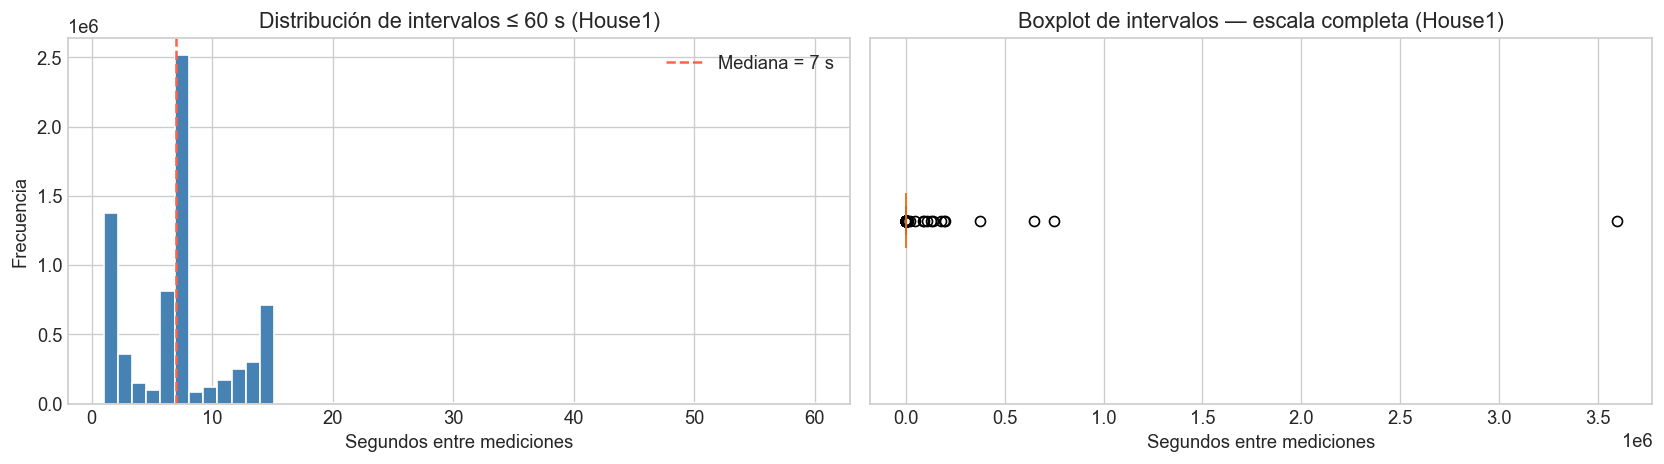

Intervalo más frecuente: 7 s
Intervalo mediano       : 7 s
Intervalo máximo        : 998.45 h (3594413 s)


In [6]:
# ============================================================
# Distribución de intervalos entre mediciones (House1)
# Confirma la granularidad de ~8 segundos declarada en la documentación
# ============================================================

intervalos_h1 = datos['House1'].index.to_series().diff().dropna().dt.total_seconds()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma acotado a 0–60 s para ver el grueso
axes[0].hist(intervalos_h1[intervalos_h1 <= 60], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de intervalos ≤ 60 s (House1)')
axes[0].set_xlabel('Segundos entre mediciones')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(intervalos_h1.median(), color='tomato', linestyle='--',
                label=f'Mediana = {intervalos_h1.median():.0f} s')
axes[0].legend()

# Diagrama de caja para ver outliers / gaps
axes[1].boxplot(intervalos_h1, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de intervalos — escala completa (House1)')
axes[1].set_xlabel('Segundos entre mediciones')
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '01_intervalos_temporales.png'), bbox_inches='tight')
plt.show()
print(f'Intervalo más frecuente: {intervalos_h1.mode().iloc[0]:.0f} s')
print(f'Intervalo mediano       : {intervalos_h1.median():.0f} s')
print(f'Intervalo máximo        : {intervalos_h1.max()/3600:.2f} h ({intervalos_h1.max():.0f} s)')

## 5. Valores nulos y columna Issues <a id='5'></a>

In [7]:
# ============================================================
# Análisis de valores nulos por hogar y columna
# ============================================================

print('=== Valores nulos por hogar ===')
for hogar, df in datos.items():
    nulos = df.isnull().sum()
    total_nulos = nulos.sum()
    pct = total_nulos / df.size * 100
    print(f'\n{hogar}: {total_nulos} nulos en total ({pct:.4f}% del dataset)')
    if total_nulos > 0:
        print(nulos[nulos > 0].to_string())
    else:
        print('  Sin valores nulos.')

=== Valores nulos por hogar ===



House1: 0 nulos en total (0.0000% del dataset)
  Sin valores nulos.

House2: 0 nulos en total (0.0000% del dataset)
  Sin valores nulos.



House3: 0 nulos en total (0.0000% del dataset)
  Sin valores nulos.


,Issues=0 (correctos),Issues=1 (problemáticos),% problemáticos
Hogar,,,
House1,"6,901,825","58,183",0.84%
House2,"5,705,082","28,444",0.50%
House3,"6,585,967","408,627",5.84%


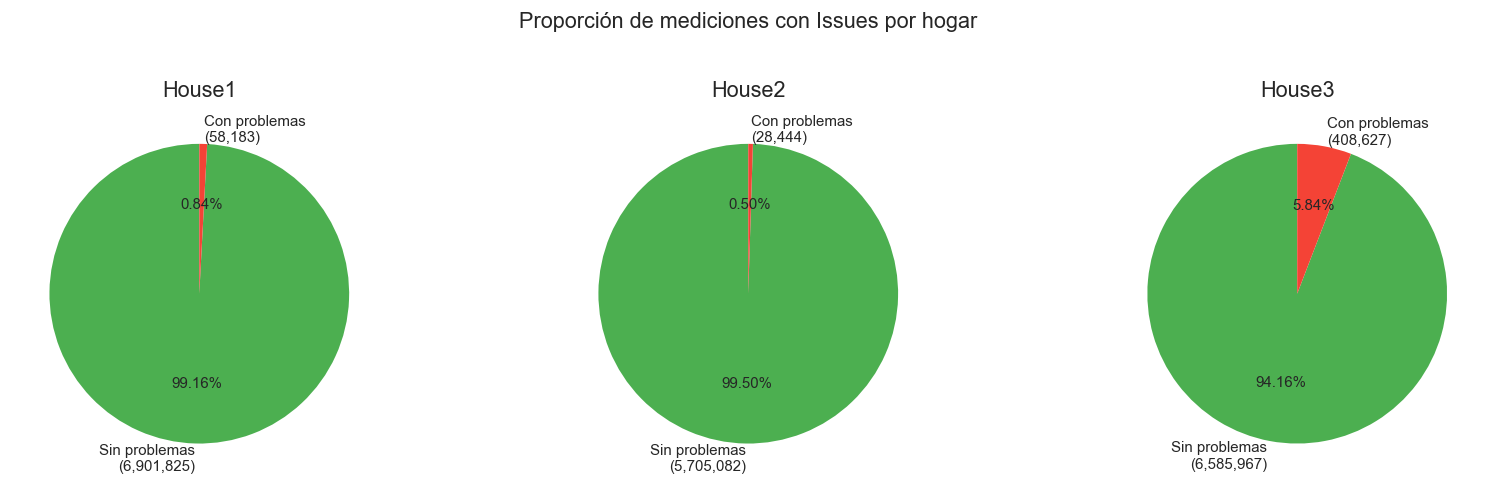

In [8]:
# ============================================================
# Análisis de la columna Issues (flag de calidad del dato)
# 0 = medición correcta | 1 = medición problemática
# ============================================================

resumen_issues = []
for hogar, df in datos.items():
    conteo = df['Issues'].value_counts().sort_index()
    n_problemas = conteo.get(1, 0)
    pct = n_problemas / len(df) * 100
    resumen_issues.append({
        'Hogar': hogar,
        'Issues=0 (correctos)': f"{conteo.get(0, 0):,}",
        'Issues=1 (problemáticos)': f"{n_problemas:,}",
        '% problemáticos': f'{pct:.2f}%'
    })

display(pd.DataFrame(resumen_issues).set_index('Hogar'))

# Visualización: proporción de Issues por hogar
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (hogar, df) in zip(axes, datos.items()):
    conteo = df['Issues'].value_counts().sort_index()
    ax.pie(
        conteo.values,
        labels=[f'Sin problemas\n({conteo.get(0,0):,})', f'Con problemas\n({conteo.get(1,0):,})'],
        colors=['#4CAF50', '#F44336'],
        autopct='%1.2f%%',
        startangle=90,
        textprops={'fontsize': 9}
    )
    ax.set_title(hogar)
plt.suptitle('Proporción de mediciones con Issues por hogar', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '01_issues_por_hogar.png'), bbox_inches='tight')
plt.show()

## 6. Duplicados <a id='6'></a>

In [9]:
# ============================================================
# Comprobación de timestamps duplicados (índice repetido)
# ============================================================

print('=== Timestamps duplicados ===')
for hogar, df in datos.items():
    n_dup = df.index.duplicated().sum()
    pct   = n_dup / len(df) * 100
    estado = '⚠️  ATENCIÓN' if n_dup > 0 else 'OK'
    print(f'  {hogar}: {n_dup:,} duplicados ({pct:.4f}%)  [{estado}]')

print('\n=== Filas completamente duplicadas ===')
for hogar, df in datos.items():
    n_dup = df.duplicated().sum()
    estado = '⚠️  ATENCIÓN' if n_dup > 0 else 'OK'
    print(f'  {hogar}: {n_dup:,} filas duplicadas  [{estado}]')

=== Timestamps duplicados ===
  House1: 0 duplicados (0.0000%)  [OK]
  House2: 0 duplicados (0.0000%)  [OK]
  House3: 0 duplicados (0.0000%)  [OK]

=== Filas completamente duplicadas ===


  House1: 0 filas duplicadas  [OK]


  House2: 0 filas duplicadas  [OK]


  House3: 0 filas duplicadas  [OK]


## 7. Estadísticas descriptivas <a id='7'></a>

In [10]:
# ============================================================
# Estadísticas descriptivas de las columnas numéricas
# Excluimos Unix (timestamp) y la columna categórica 'hogar'
# ============================================================

columnas_consumo = ['Aggregate'] + [f'Appliance{i}' for i in range(1, 10)]

for hogar, df in datos.items():
    print(f'\n=== Estadísticas descriptivas — {hogar} (vatios) ===')
    stats = df[columnas_consumo].describe().round(1)
    display(stats)


=== Estadísticas descriptivas — House1 (vatios) ===


,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9
count,6960008.0,6960008.0,6960008.0,6960008.0,6960008.0,6960008.0,6960008.0,6960008.0,6960008.0,6960008.0
mean,481.1,17.5,16.6,29.0,1.8,11.0,11.2,2.5,5.8,69.5
std,812.9,43.1,28.8,38.0,56.1,143.9,156.8,11.9,13.2,255.8
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,185.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
50%,242.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
75%,427.0,0.0,45.0,70.0,0.0,0.0,0.0,0.0,0.0,1.0
max,29159.0,3584.0,3452.0,3657.0,3584.0,3072.0,2525.0,2094.0,3584.0,2119.0



=== Estadísticas descriptivas — House2 (vatios) ===


,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9
count,5733526.0,5733526.0,5733526.0,5733526.0,5733526.0,5733526.0,5733526.0,5733526.0,5733526.0,5733526.0
mean,465.1,35.8,18.3,61.5,4.0,3.3,1.5,1.7,23.2,0.4
std,1062.6,45.7,174.3,352.3,13.4,58.6,38.0,5.7,249.4,5.4
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,108.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,168.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,331.0,84.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,24595.0,1690.0,3584.0,3092.0,3584.0,3072.0,3968.0,3040.0,3729.0,2048.0



=== Estadísticas descriptivas — House3 (vatios) ===


,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9
count,6994594.0,6994594.0,6994594.0,6994594.0,6994594.0,6994594.0,6994594.0,6994594.0,6994594.0,6994594.0
mean,678.5,1.7,53.2,36.3,55.3,49.1,28.9,48.4,2.7,19.6
std,1013.2,41.5,60.2,48.3,351.5,310.9,212.0,68.2,59.6,189.3
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,223.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,368.0,0.0,81.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,613.0,0.0,94.0,88.0,0.0,0.0,0.0,143.0,0.0,0.0
max,65836.0,2201.0,3584.0,2140.0,2820.0,3840.0,2746.0,3728.0,2848.0,2277.0


In [11]:
# ============================================================
# Detección de valores negativos (físicamente imposibles en consumo)
# ============================================================

print('=== Valores negativos en columnas de consumo ===')
for hogar, df in datos.items():
    negativos = (df[columnas_consumo] < 0).sum()
    total_neg = negativos.sum()
    estado = '⚠️  ATENCIÓN' if total_neg > 0 else 'OK'
    print(f'\n{hogar}: {total_neg} valores negativos  [{estado}]')
    if total_neg > 0:
        print(negativos[negativos > 0].to_string())

=== Valores negativos en columnas de consumo ===



House1: 0 valores negativos  [OK]

House2: 0 valores negativos  [OK]



House3: 0 valores negativos  [OK]


## 8. Distribución del consumo agregado <a id='8'></a>

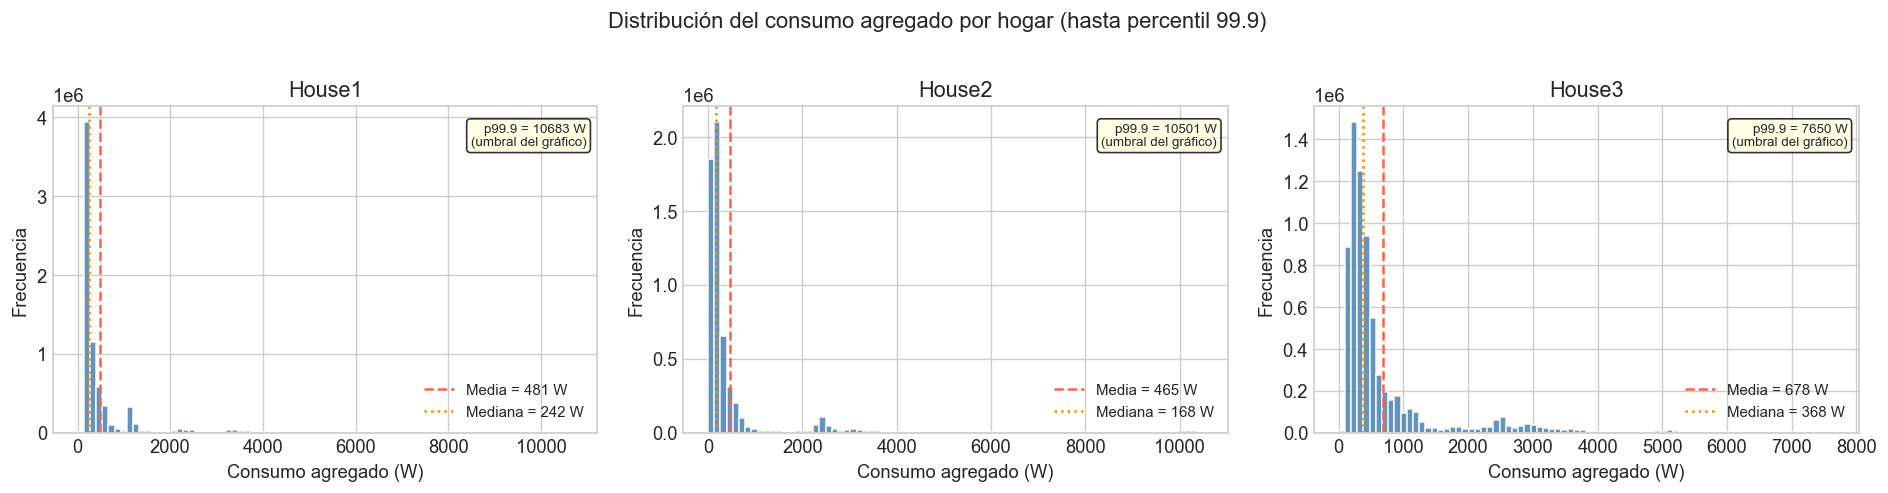

In [12]:
# ============================================================
# Distribución del consumo agregado por hogar
# Se filtran outliers extremos (> 99.9 percentil) para la visualización
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (hogar, df) in zip(axes, datos.items()):
    consumo = df['Aggregate']
    umbral  = consumo.quantile(0.999)
    consumo_filtrado = consumo[consumo <= umbral]

    ax.hist(consumo_filtrado, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(consumo.mean(),   color='tomato',    linestyle='--', lw=1.5,
               label=f'Media = {consumo.mean():.0f} W')
    ax.axvline(consumo.median(), color='darkorange', linestyle=':',  lw=1.5,
               label=f'Mediana = {consumo.median():.0f} W')
    ax.set_title(hogar)
    ax.set_xlabel('Consumo agregado (W)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
    ax.text(0.98, 0.95, f'p99.9 = {umbral:.0f} W\n(umbral del gráfico)',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

plt.suptitle('Distribución del consumo agregado por hogar (hasta percentil 99.9)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '01_distribucion_consumo.png'), bbox_inches='tight')
plt.show()

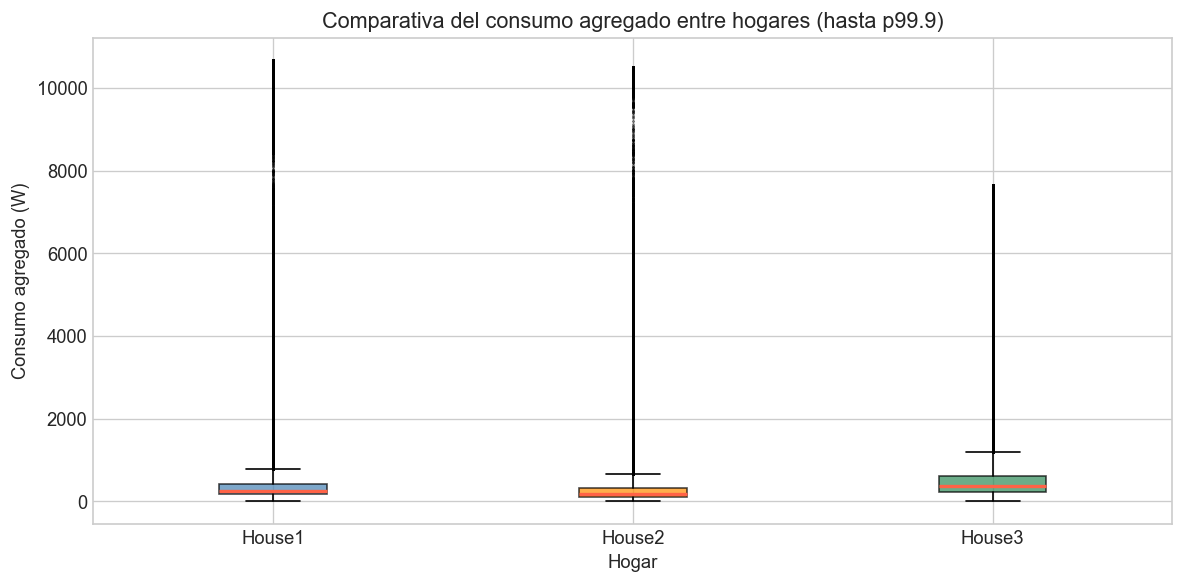

In [13]:
# ============================================================
# Boxplot comparativo del consumo agregado entre hogares
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

datos_box = [df['Aggregate'].clip(upper=df['Aggregate'].quantile(0.999))
             for df in datos.values()]

bp = ax.boxplot(
    datos_box,
    labels=HOGARES,
    patch_artist=True,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color='tomato', lw=2),
    flierprops=dict(marker='.', markersize=1, alpha=0.3)
)
colores = ['steelblue', 'darkorange', 'seagreen']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)

ax.set_title('Comparativa del consumo agregado entre hogares (hasta p99.9)')
ax.set_ylabel('Consumo agregado (W)')
ax.set_xlabel('Hogar')
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '01_boxplot_comparativo.png'), bbox_inches='tight')
plt.show()

## 9. Series temporales — primeros 7 días <a id='9'></a>

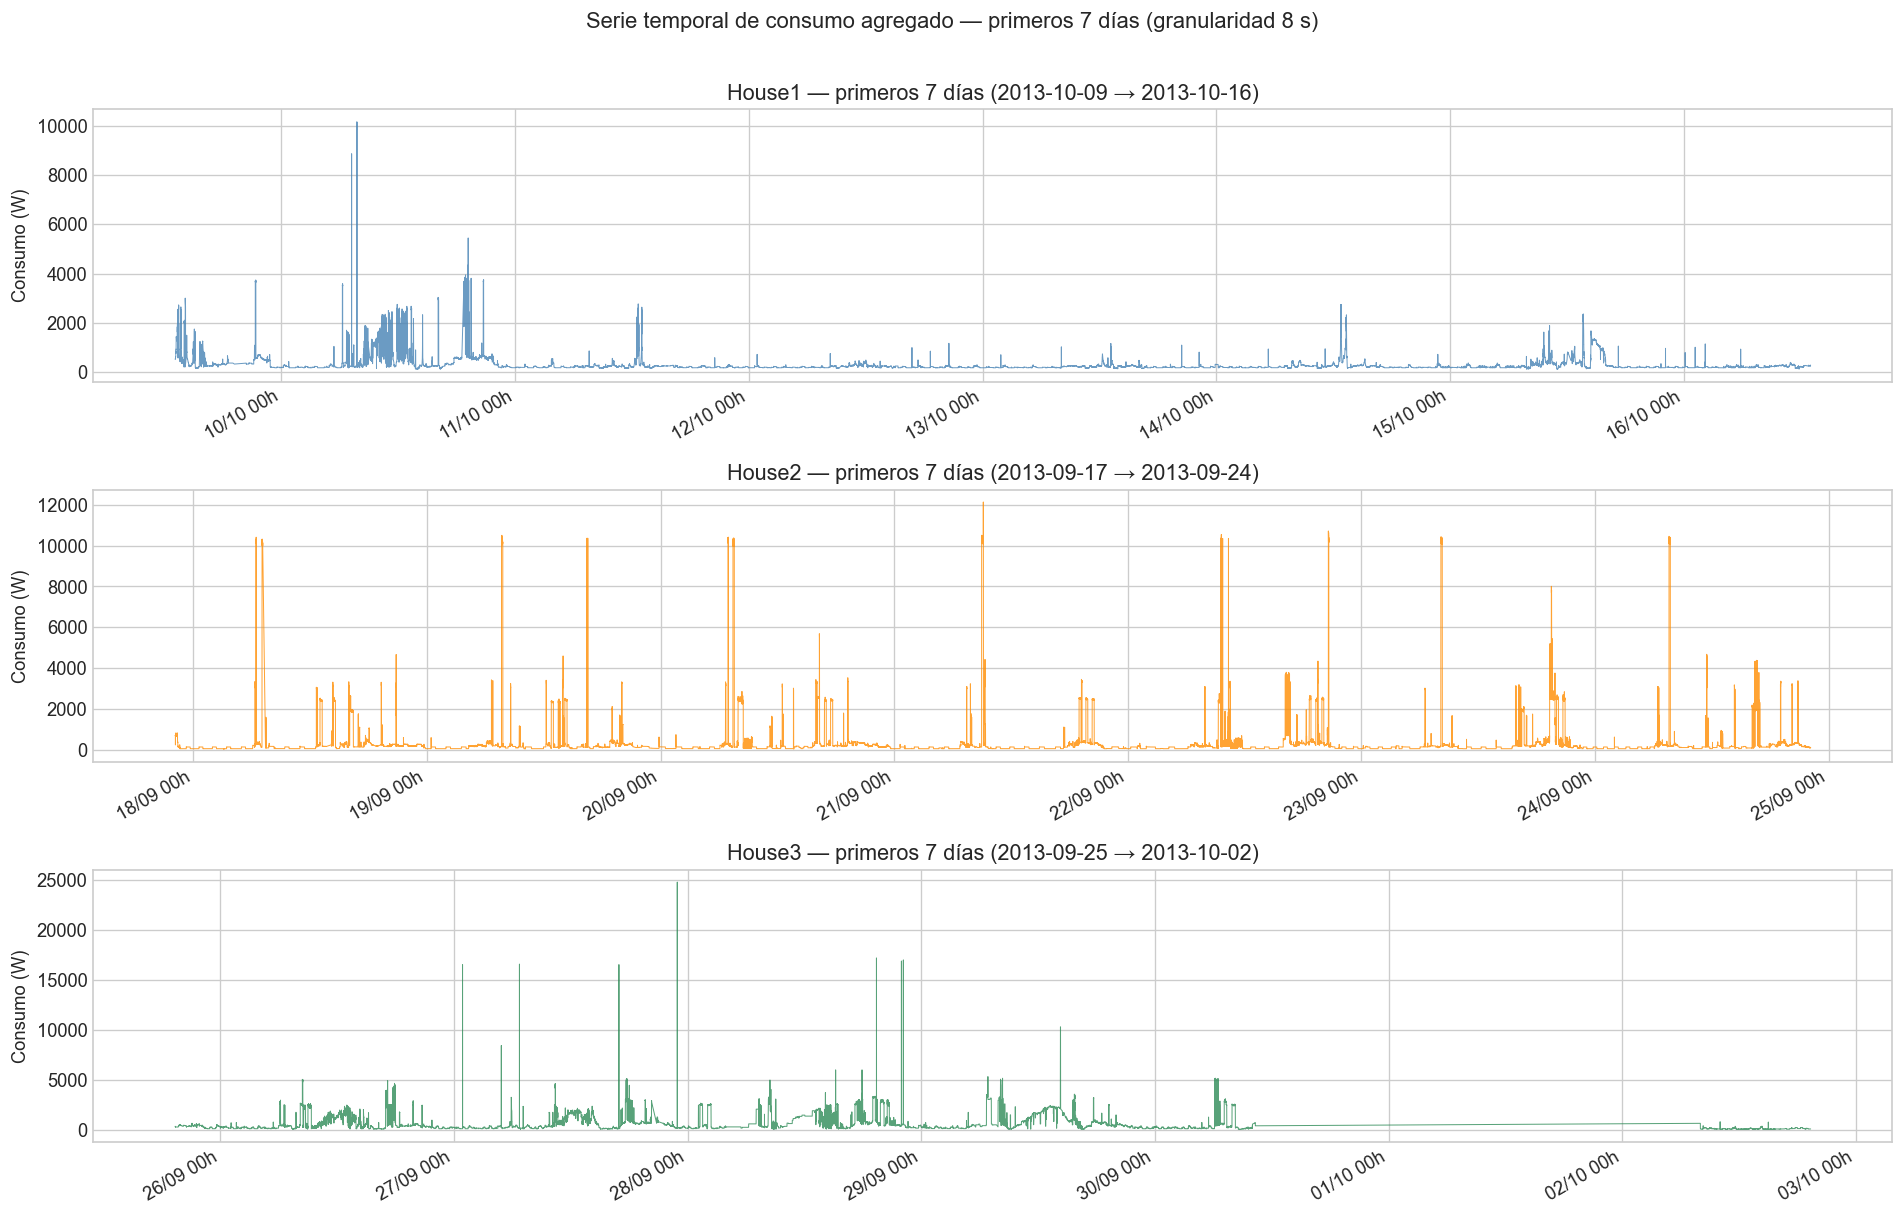

In [14]:
# ============================================================
# Visualización de la serie temporal de consumo agregado
# Se muestran los primeros 7 días de cada hogar para ver
# los patrones diarios y el nivel de ruido a 8 segundos
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

for ax, (hogar, df), color in zip(axes, datos.items(), ['steelblue', 'darkorange', 'seagreen']):
    inicio_hogar = df.index.min()
    fin_7d = inicio_hogar + pd.Timedelta(days=7)
    segmento = df.loc[inicio_hogar:fin_7d, 'Aggregate']

    ax.plot(segmento.index, segmento.values, color=color, lw=0.6, alpha=0.8)
    ax.set_title(f'{hogar} — primeros 7 días ({inicio_hogar.date()} → {fin_7d.date()})')
    ax.set_ylabel('Consumo (W)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Serie temporal de consumo agregado — primeros 7 días (granularidad 8 s)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '01_serie_temporal_7dias.png'), bbox_inches='tight')
plt.show()

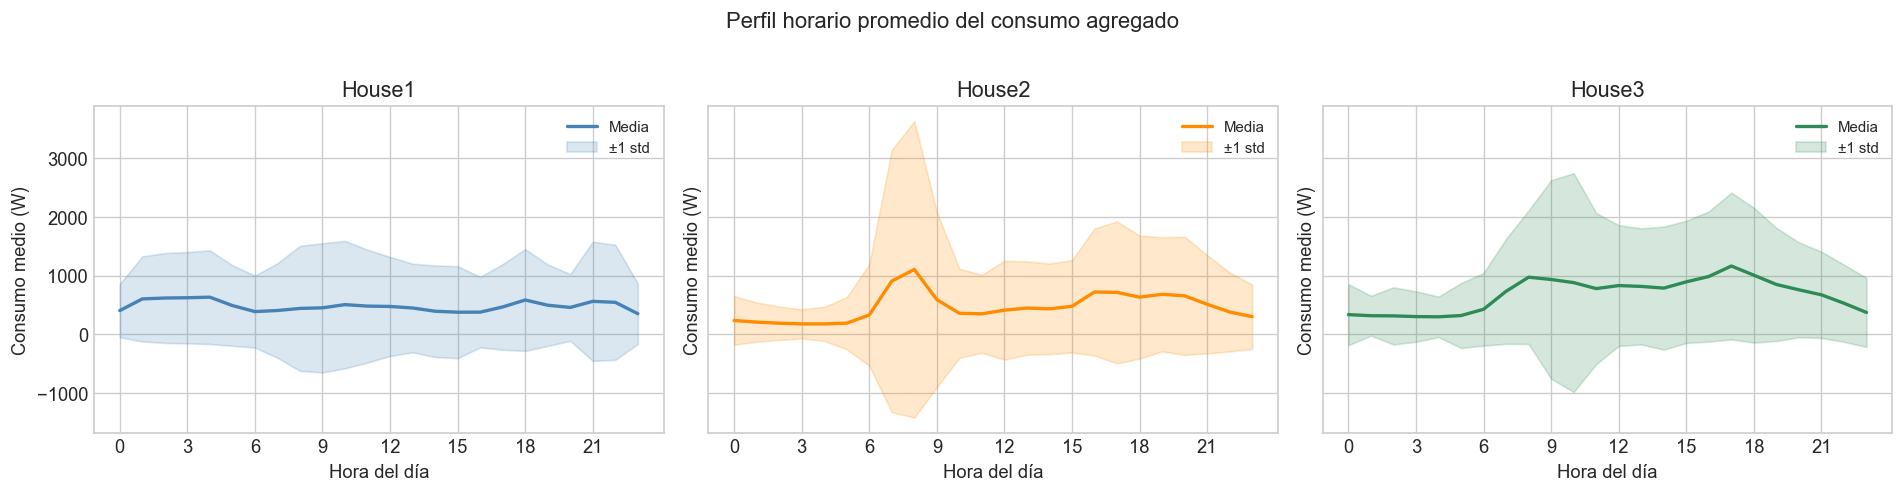

In [15]:
# ============================================================
# Perfil horario promedio (media por hora del día) — House1
# Primer indicio del patrón de consumo diario
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (hogar, df), color in zip(axes, datos.items(), ['steelblue', 'darkorange', 'seagreen']):
    perfil = df['Aggregate'].groupby(df.index.hour).agg(['mean', 'std'])
    horas  = perfil.index

    ax.plot(horas, perfil['mean'], color=color, lw=2, label='Media')
    ax.fill_between(
        horas,
        perfil['mean'] - perfil['std'],
        perfil['mean'] + perfil['std'],
        color=color, alpha=0.2, label='±1 std'
    )
    ax.set_title(hogar)
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('Consumo medio (W)')
    ax.set_xticks(range(0, 24, 3))
    ax.legend(fontsize=9)

plt.suptitle('Perfil horario promedio del consumo agregado', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '01_perfil_horario.png'), bbox_inches='tight')
plt.show()

## 10. Comparativa entre hogares <a id='10'></a>

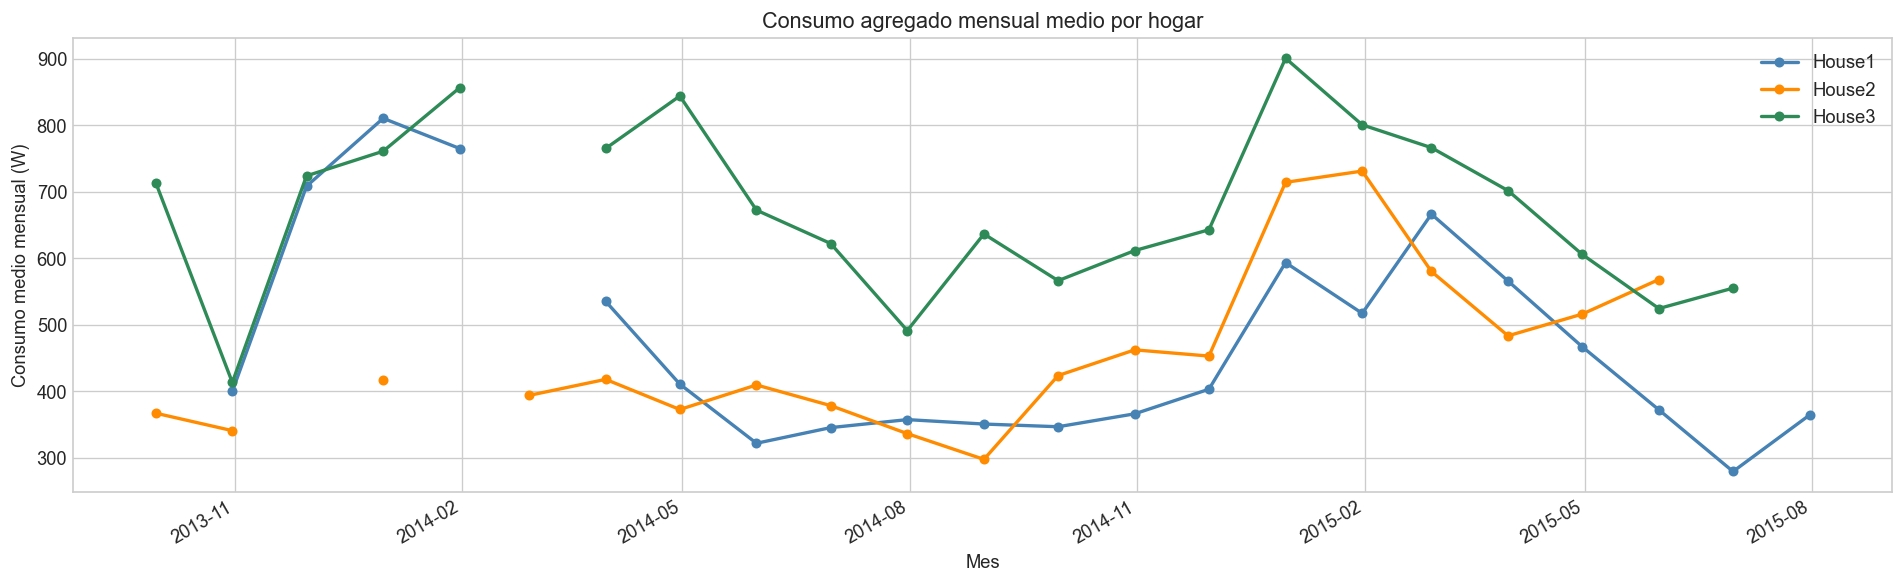

In [16]:
# ============================================================
# Comparativa mensual del consumo agregado medio
# Permite ver si los periodos temporales solapan entre hogares
# ============================================================

fig, ax = plt.subplots(figsize=(16, 5))

for (hogar, df), color in zip(datos.items(), ['steelblue', 'darkorange', 'seagreen']):
    mensual = df['Aggregate'].resample('ME').mean()
    ax.plot(mensual.index, mensual.values, marker='o', lw=2,
            color=color, label=hogar, markersize=5)

ax.set_title('Consumo agregado mensual medio por hogar')
ax.set_ylabel('Consumo medio mensual (W)')
ax.set_xlabel('Mes')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '01_consumo_mensual.png'), bbox_inches='tight')
plt.show()

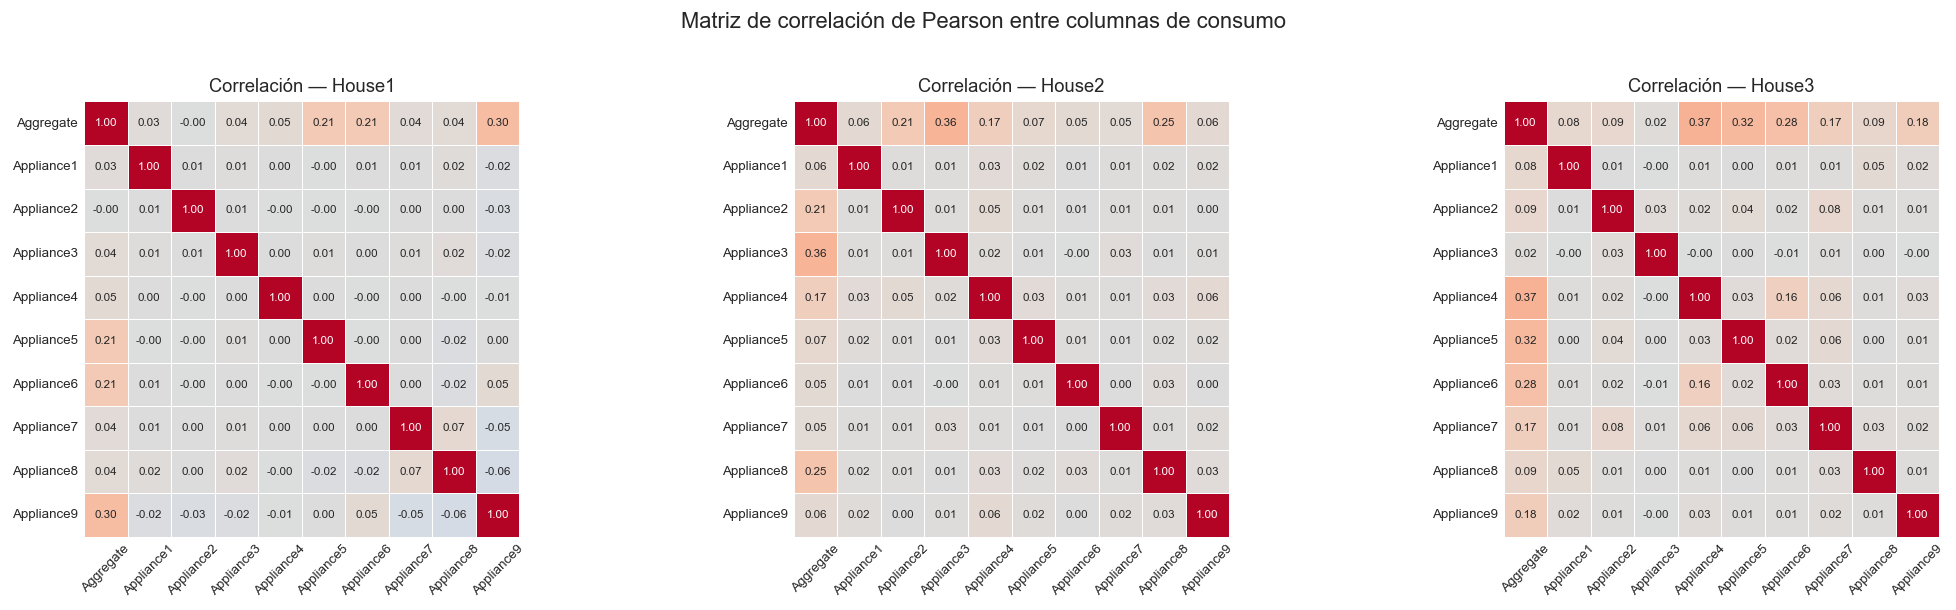

In [17]:
# ============================================================
# Correlación entre electrodomésticos — House1
# Mapa de calor de correlaciones de Pearson
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (hogar, df) in zip(axes, datos.items()):
    corr = df[columnas_consumo].corr()
    mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)  # triángulo superior
    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        annot_kws={'size': 7},
        square=True,
        cbar=False
    )
    ax.set_title(f'Correlación — {hogar}', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Matriz de correlación de Pearson entre columnas de consumo', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '01_correlacion_consumo.png'), bbox_inches='tight')
plt.show()

## 11. Resumen final <a id='11'></a>

In [18]:
# ============================================================
# Tabla resumen ejecutivo para incluir en la memoria académica
# ============================================================

filas_resumen = []
for hogar, df in datos.items():
    consumo = df['Aggregate']
    intervalos = df.index.to_series().diff().dropna().dt.total_seconds()
    n_issues = (df['Issues'] == 1).sum()
    n_neg    = (df[columnas_consumo] < 0).any(axis=1).sum()
    n_dup    = df.index.duplicated().sum()

    filas_resumen.append({
        'Hogar'              : hogar,
        'Inicio'             : df.index.min().strftime('%Y-%m-%d'),
        'Fin'                : df.index.max().strftime('%Y-%m-%d'),
        'Días'               : (df.index.max() - df.index.min()).days,
        'Registros'          : f'{len(df):,}',
        'Intervalo med. (s)' : f'{intervalos.median():.0f}',
        'Consumo medio (W)'  : f'{consumo.mean():.1f}',
        'Consumo max (W)'    : f'{consumo.max():,}',
        'Nulos'              : df.isnull().sum().sum(),
        'Issues=1'           : f'{n_issues:,}',
        '% Issues'           : f'{n_issues/len(df)*100:.2f}%',
        'Negativos'          : n_neg,
        'Timestamps dup.'    : n_dup,
    })

df_resumen = pd.DataFrame(filas_resumen).set_index('Hogar')
print('=== RESUMEN EJECUTIVO — INSPECCIÓN INICIAL ===')
display(df_resumen.T)

# Guardar como CSV para la memoria
df_resumen.to_csv('../resultados/metricas/01_resumen_inspeccion.csv')
print('\nResumen guardado en: resultados/metricas/01_resumen_inspeccion.csv')

=== RESUMEN EJECUTIVO — INSPECCIÓN INICIAL ===


Hogar,House1,House2,House3
Inicio,2013-10-09,2013-09-17,2013-09-25
Fin,2015-07-10,2015-05-28,2015-06-02
Días,638,617,614
Registros,"6,960,008","5,733,526","6,994,594"
Intervalo med. (s),7,7,7
Consumo medio (W),481.1,465.1,678.5
Consumo max (W),"29,159","24,595","65,836"
Nulos,0,0,0
Issues=1,"58,183","28,444","408,627"
% Issues,0.84%,0.50%,5.84%



Resumen guardado en: resultados/metricas/01_resumen_inspeccion.csv


In [19]:
# ============================================================
# Figuras generadas en este notebook
# ============================================================

figuras_generadas = [
    '01_intervalos_temporales.png',
    '01_issues_por_hogar.png',
    '01_distribucion_consumo.png',
    '01_boxplot_comparativo.png',
    '01_serie_temporal_7dias.png',
    '01_perfil_horario.png',
    '01_consumo_mensual.png',
    '01_correlacion_consumo.png',
]

print('=== Figuras exportadas a resultados/figuras/ ===')
for f in figuras_generadas:
    ruta_completa = os.path.join(RUTA_FIGS, f)
    existe = os.path.exists(ruta_completa)
    print(f'  {"OK" if existe else "FALTA":5s}  {f}')

print('\n=== Notebook 01 completado correctamente ===')
print('Próximo paso: Notebook 02 — Limpieza de datos')
print('  - Tratamiento de Issues=1')
print('  - Eliminación de negativos')
print('  - Gestión de timestamps duplicados')
print('  - Remuestreo de 8 s a 1 minuto')

=== Figuras exportadas a resultados/figuras/ ===
  OK     01_intervalos_temporales.png
  OK     01_issues_por_hogar.png
  OK     01_distribucion_consumo.png
  OK     01_boxplot_comparativo.png
  OK     01_serie_temporal_7dias.png
  OK     01_perfil_horario.png
  OK     01_consumo_mensual.png
  OK     01_correlacion_consumo.png

=== Notebook 01 completado correctamente ===
Próximo paso: Notebook 02 — Limpieza de datos
  - Tratamiento de Issues=1
  - Eliminación de negativos
  - Gestión de timestamps duplicados
  - Remuestreo de 8 s a 1 minuto
